In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
from src.data_loader import *

df = load_data("../data/raw/dataset-diabete.csv")
df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['Unnamed: 0', 'Pregnancies', 'Glucose', 'BloodPressure',
       'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


# Data Dictionary

Source: `data/raw/dataset-diabete.csv` (768 patients, similar to the Pima Indians Diabetes dataset)

| Column | Meaning | Unit | Typical range | Problem in our data | Planned action |
|---|---|---|---|---|---|
| `Unnamed: 0` | Old row index saved by mistake | none | 0 to 767 | No medical meaning | Drop |
| `Pregnancies` | Number of times the patient has been pregnant | count | 0 to 17 | None (0 is valid) | Keep or drop (decide later) |
| `Glucose` | Blood sugar 2 hours after drinking a glucose solution (oral glucose tolerance test) | mg/dL | about 70 to 200 | Zeros are impossible | Zero to NaN, then impute |
| `BloodPressure` | Diastolic blood pressure (the lower number) | mm Hg | about 60 to 90 | Zeros are impossible | Zero to NaN, then impute |
| `SkinThickness` | Triceps skinfold thickness, an indirect measure of body fat | mm | about 10 to 50 | Many zeros (over 25% of rows) | Zero to NaN, then impute |
| `Insulin` | Insulin level in the blood 2 hours after the glucose test | mu U/ml | about 15 to 276 | Many zeros, very skewed, max 846 | Zero to NaN, impute, check outliers |
| `BMI` | Body Mass Index = weight (kg) / height (m)Ã‚Â² | kg/mÃ‚Â² | 18.5 to 40 | Zeros are impossible | Zero to NaN, then impute |
| `DiabetesPedigreeFunction` | Score of diabetes history in the family, weighted by how close the relatives are | no unit | 0.08 to 2.42 | Right-skewed, possible outliers | Keep, check outliers |
| `Age` | Age of the patient | years | 21 to 81 | Right-skewed | Keep, check outliers |

## Risk thresholds used in the project
- Glucose > 126
- BMI > 30
- DiabetesPedigreeFunction > 0.5

## Notes
- There is no "Outcome" column (diabetic yes/no). That is why we use K-Means to create groups first.
- Zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI mean "not measured".

In [8]:
from src.preprocessing import *
df = drop_column(df,"Unnamed: 0")
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [9]:
from src.eda import *

column_info(df, "Glucose")

,Section,Metric,Value
0,General,Data type,int64
1,General,Total rows,768
2,General,Unique values,136
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,5 (0.7%)
5,Distribution,Min,0
6,Distribution,Max,199
7,Distribution,Mean,120.89
8,Distribution,Median,117.0
9,Distribution,Std deviation,31.97


In [10]:
# df = zeros_to_nan(df, "Glucose")
# column_info(df, "Glucose")

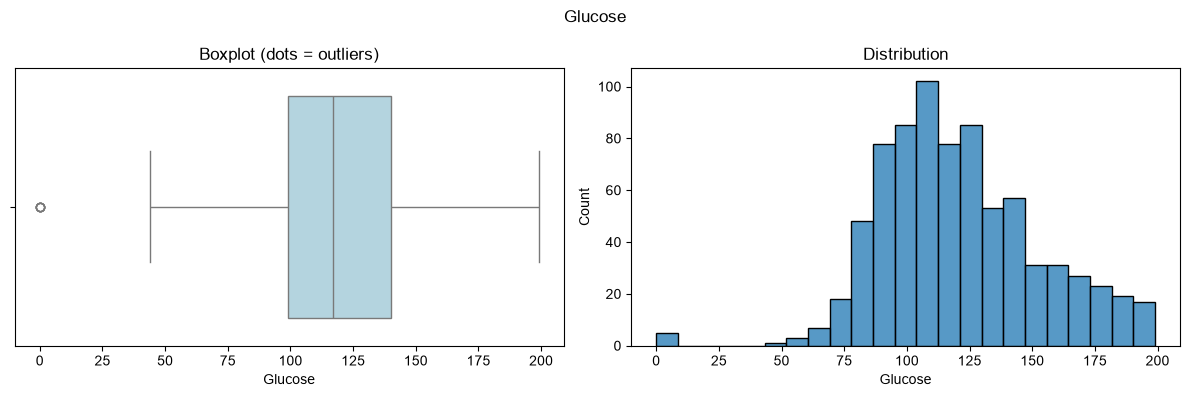

In [11]:
graphe_check_outliers(df, "Glucose")

In [12]:
missing = df["Glucose"].isna()
df.groupby(missing)[["BMI", "Age", "BloodPressure"]].median()

,BMI,Age,BloodPressure
Glucose,,,
False,32.0,29.0,72.0


In [13]:
# df = handle_missing(df, "Glucose")
# column_info(df, "Glucose")

let's start with BloodPressure 

In [14]:
column_info(df, "BloodPressure")

,Section,Metric,Value
0,General,Data type,int64
1,General,Total rows,768
2,General,Unique values,47
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,35 (4.6%)
5,Distribution,Min,0
6,Distribution,Max,122
7,Distribution,Mean,69.11
8,Distribution,Median,72.0
9,Distribution,Std deviation,19.36


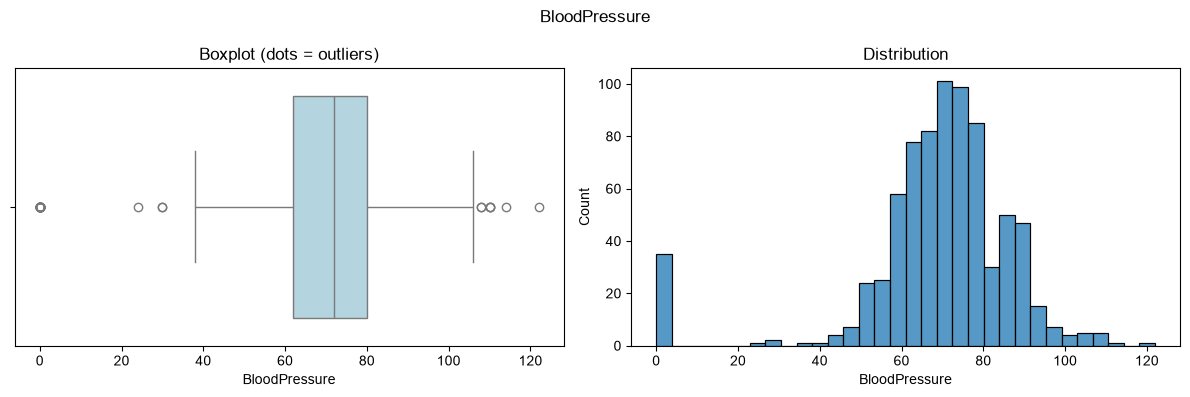

In [15]:
graphe_check_outliers(df, "BloodPressure")

In [16]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')


Pregnancies


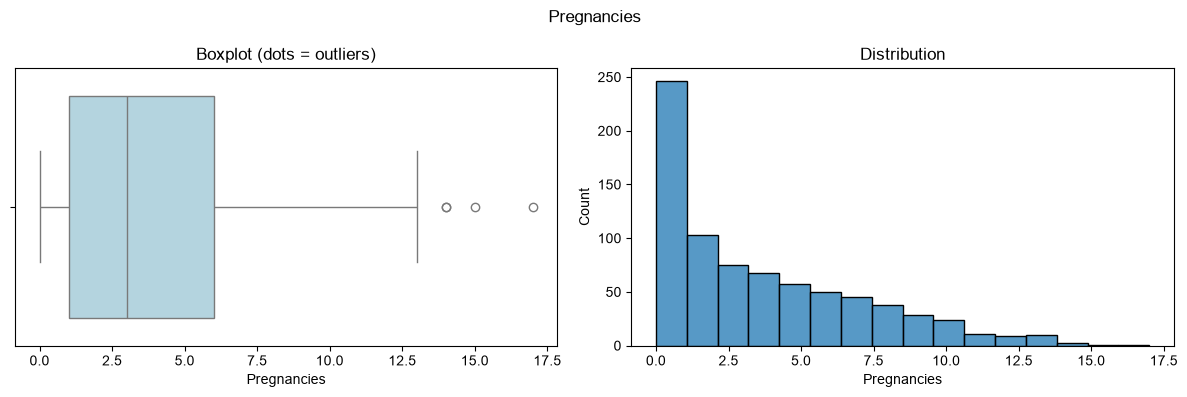

Glucose


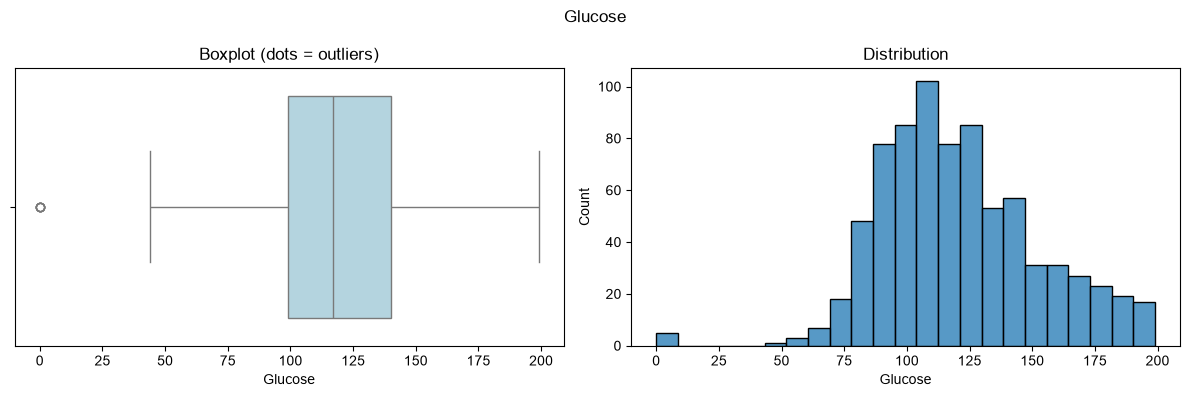

BloodPressure


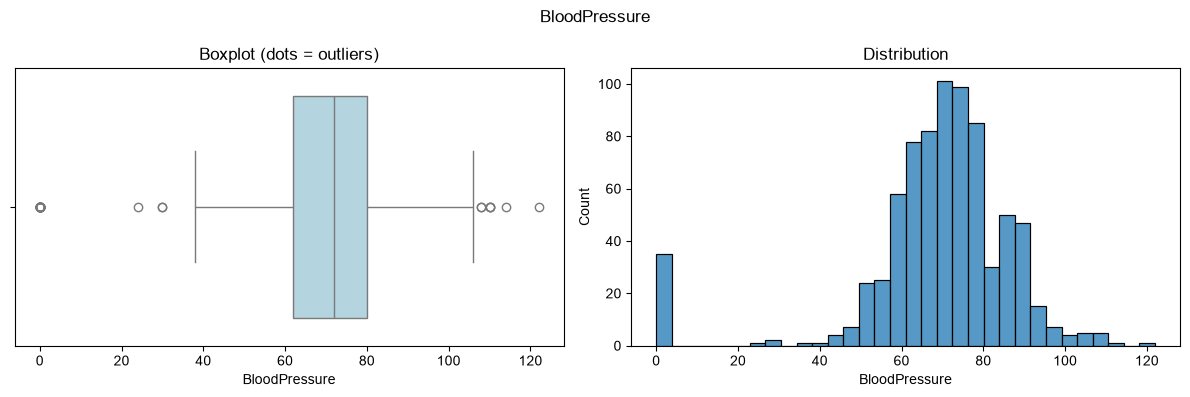

SkinThickness


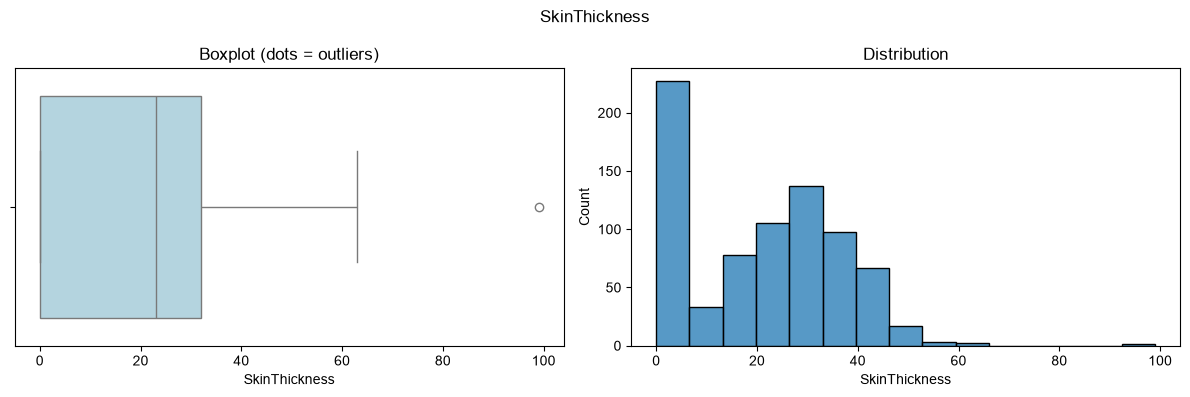

Insulin


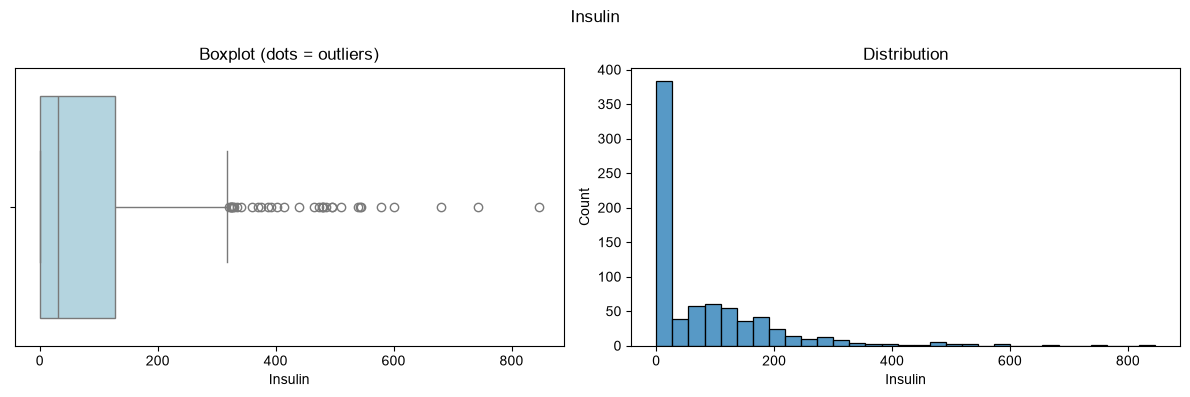

BMI


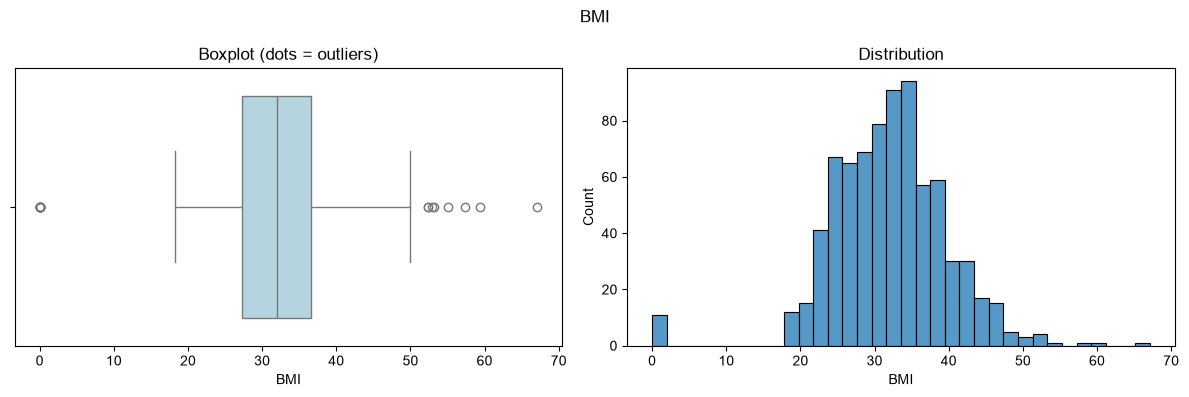

DiabetesPedigreeFunction


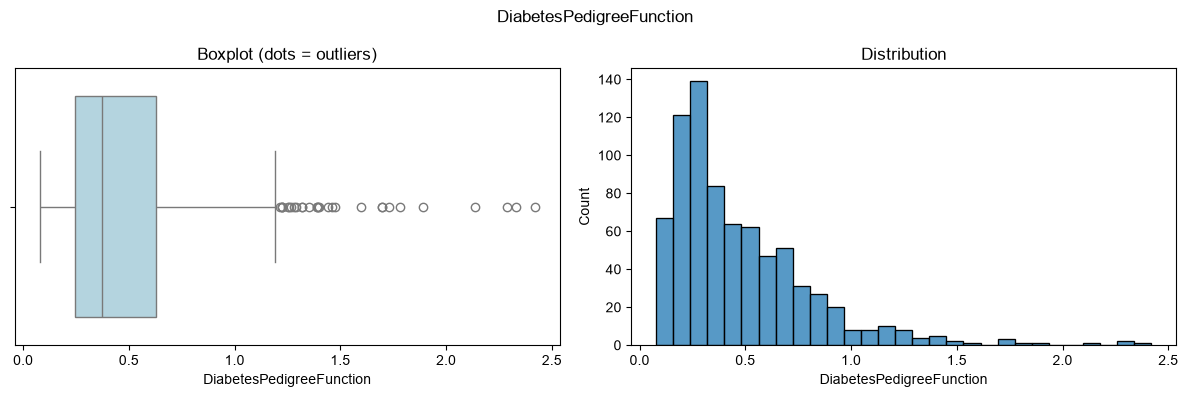

Age


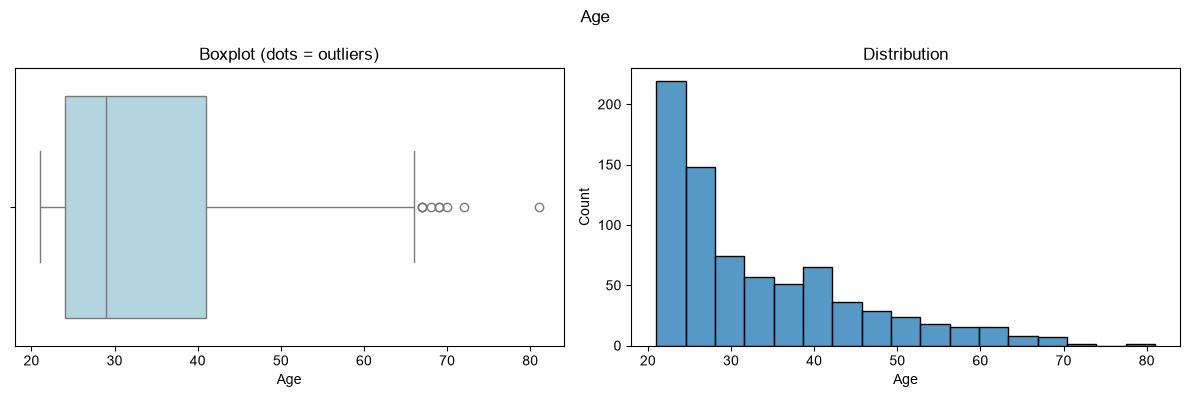

In [17]:
print("Pregnancies")
graphe_check_outliers(df, "Pregnancies")
print("Glucose")
graphe_check_outliers(df, "Glucose")
print("BloodPressure")
graphe_check_outliers(df, "BloodPressure")
print("SkinThickness")
graphe_check_outliers(df, "SkinThickness")
print("Insulin")
graphe_check_outliers(df, "Insulin")
print("BMI")
graphe_check_outliers(df, "BMI")
print("DiabetesPedigreeFunction")
graphe_check_outliers(df, "DiabetesPedigreeFunction")
print("Age")
graphe_check_outliers(df, "Age")


In [18]:
# df[df['Pregnancies']> 16]
df[df['Age'] > 65].count()

Pregnancies                 13
Glucose                     13
BloodPressure               13
SkinThickness               13
Insulin                     13
BMI                         13
DiabetesPedigreeFunction    13
Age                         13
dtype: int64

In [19]:
fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI']

for c in fake_zero:
    df = zeros_to_nan(df, c)

In [20]:
df[fake_zero].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_value = scaler.fit_transform(df[fake_zero])

df_scaled = df.copy()
df_scaled[fake_zero] = scaled_value

df_scaled[fake_zero].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,0.862287,-0.032746,0.558557,NaN,0.165097
1,-1.202229,-0.517645,-0.014657,NaN,-0.846404
2,2.009241,-0.679278,NaN,NaN,-1.323254
3,-1.071148,-0.517645,-0.587871,-0.518847,-0.629654
4,0.501816,-2.618874,0.558557,0.104968,1.537847


In [22]:
df_scaled[fake_zero].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [23]:
# back into this part and try to use cross avlidation with this values 3,5,7 
# to find what is the bast value of neighbors
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
imputed_values = imputer.fit_transform(df_scaled[fake_zero])

In [24]:
imputed_real = scaler.inverse_transform(imputed_values)
imputed_real

array([[148. ,  72. ,  35. , 196. ,  33.6],
       [ 85. ,  66. ,  29. ,  73.6,  26.6],
       [183. ,  64. ,  25.6, 218.2,  23.3],
       ...,
       [121. ,  72. ,  23. , 112. ,  26.2],
       [126. ,  60. ,  21.2, 186.8,  30.1],
       [ 93. ,  70. ,  31. , 105.8,  30.4]], shape=(768, 5))

In [25]:
df_final = df.copy()
df_final[fake_zero] = imputed_real

df_final[fake_zero].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,196.0,33.6
1,85.0,66.0,29.0,73.6,26.6
2,183.0,64.0,25.6,218.2,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1


In [26]:
df_final[fake_zero].isna().sum()
df_final

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,196.0,33.6,0.627,50
1,1,85.0,66.0,29.0,73.6,26.6,0.351,31
2,8,183.0,64.0,25.6,218.2,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,151.8,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,21.2,186.8,30.1,0.349,47


In [27]:
df_final[fake_zero].isna().sum()


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [28]:
df_final[fake_zero].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.722656,72.467188,28.605729,150.538281,32.446146
std,30.454597,12.227699,9.558563,97.412594,6.889450
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,22.000000,87.000000,27.500000
50%,117.000000,72.000000,28.100000,127.600000,32.050000
75%,141.000000,80.000000,35.000000,189.850000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


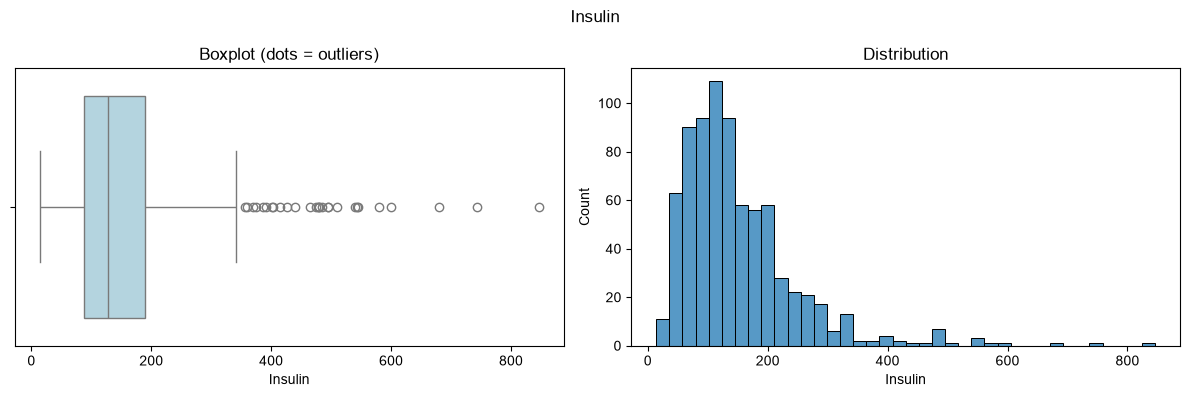

,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,471
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,14.0
6,Distribution,Max,846.0
7,Distribution,Mean,150.54
8,Distribution,Median,127.6
9,Distribution,Std deviation,97.41


In [29]:
graphe_check_outliers(df_final, "Insulin")
column_info(df_final, "Insulin")

In [30]:
fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_final = knn(
    df,
    ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'],
    ['DiabetesPedigreeFunction', 'Age', 'Pregnancies'],
)
df_final[fake_zero].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.594271,72.386719,28.998698,153.701562,32.428411
std,30.473439,12.193297,9.466083,97.815755,6.890396
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.000000,64.000000,22.800000,89.400000,27.500000
50%,117.000000,72.000000,28.800000,130.000000,32.190000
75%,140.250000,80.000000,35.000000,192.400000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


Pregnancies


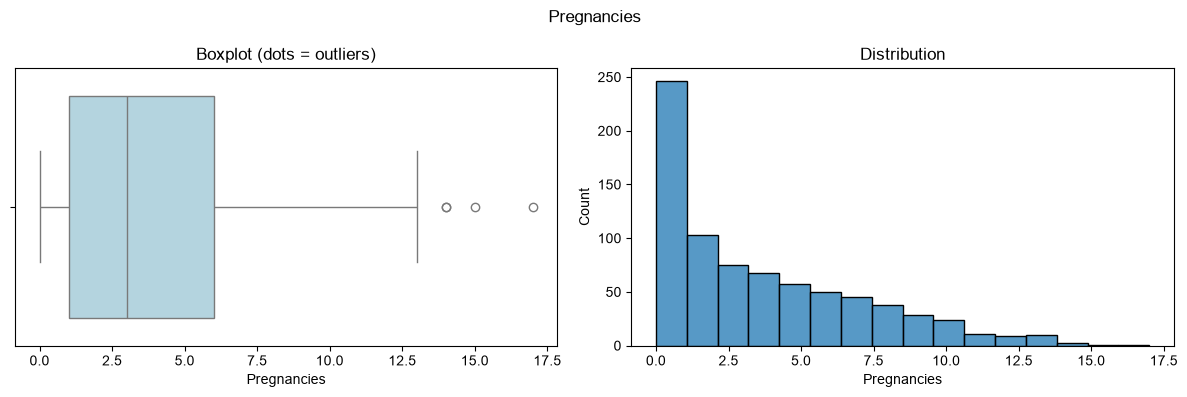

Glucose


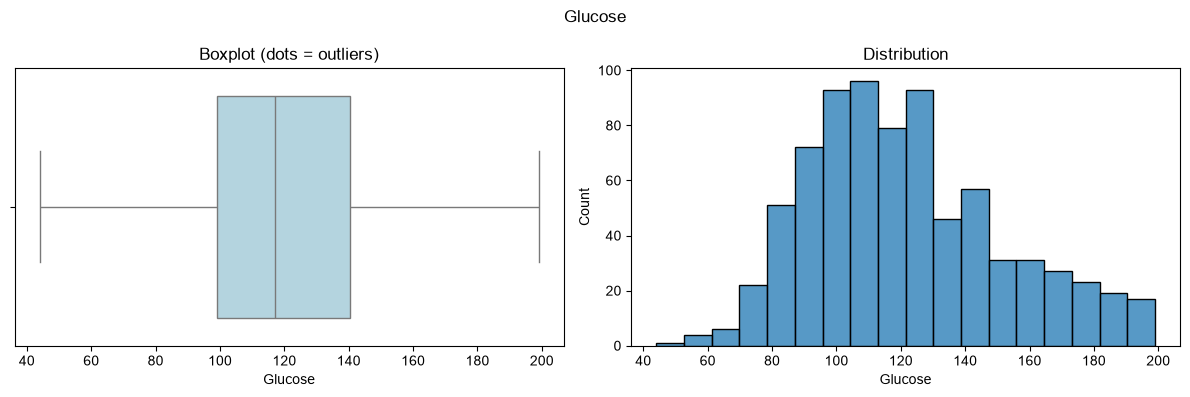

BloodPressure


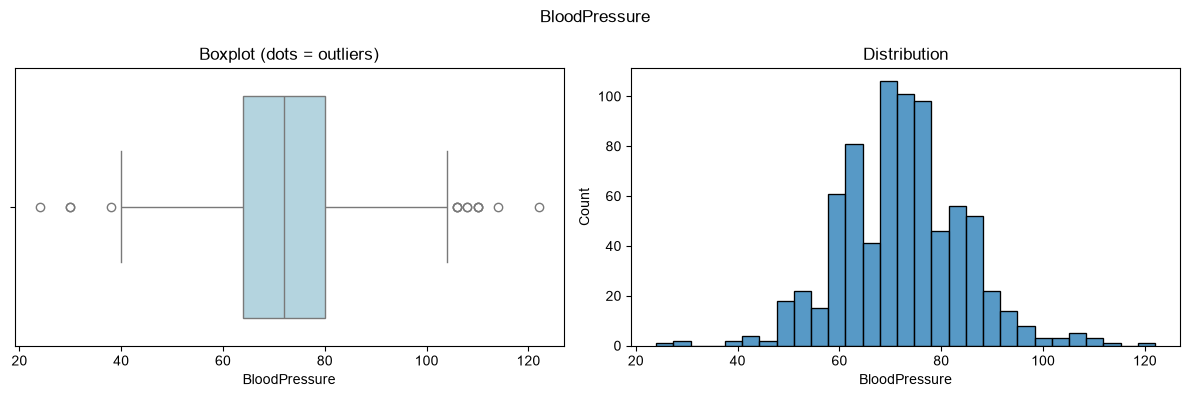

SkinThickness


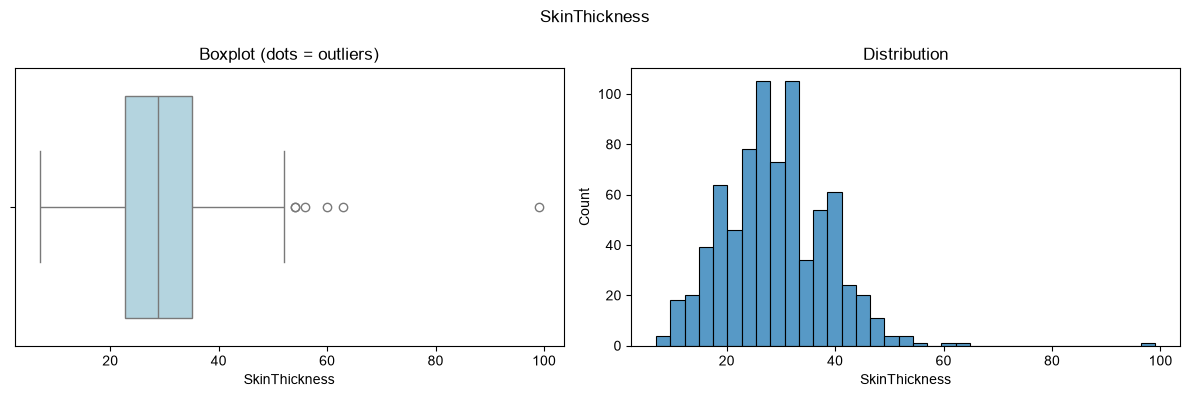

Insulin


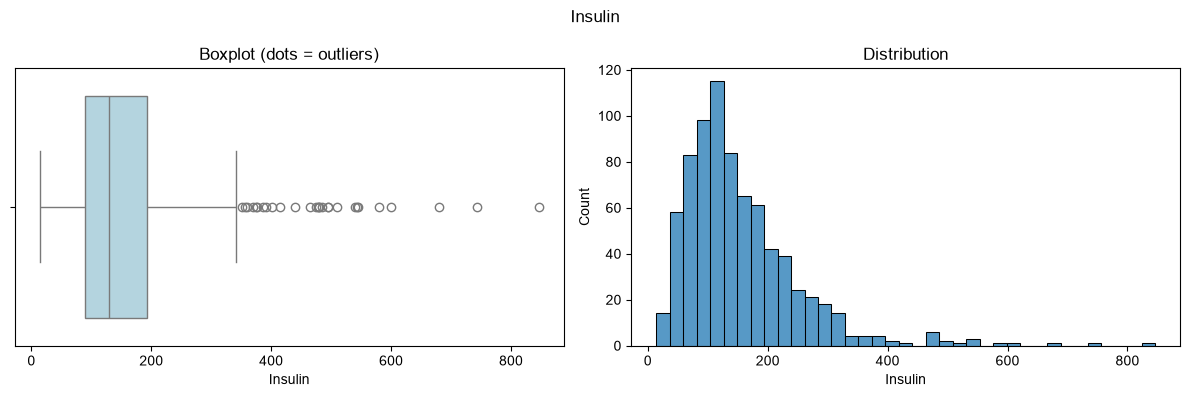

BMI


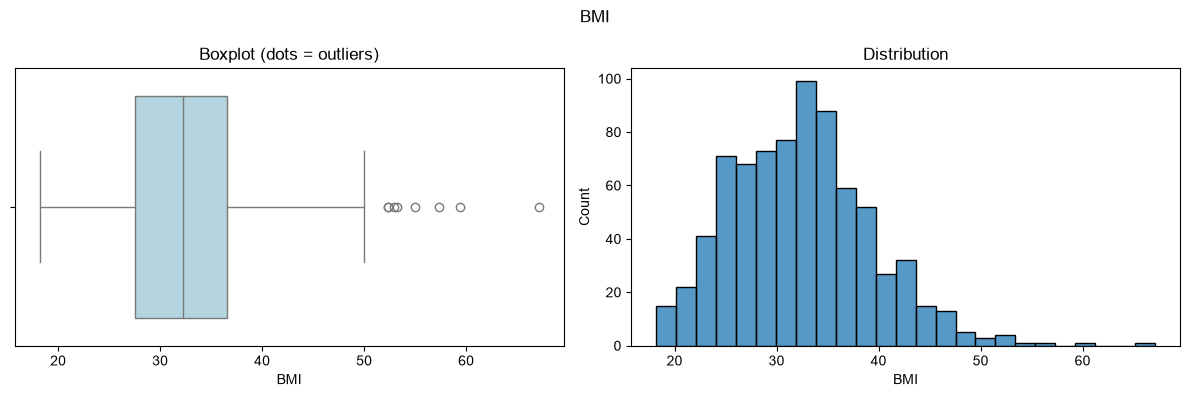

DiabetesPedigreeFunction


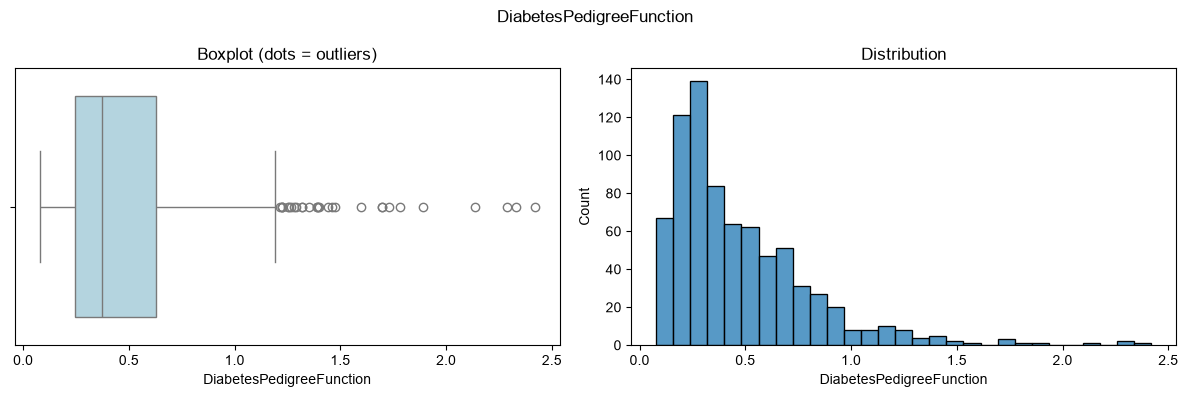

Age


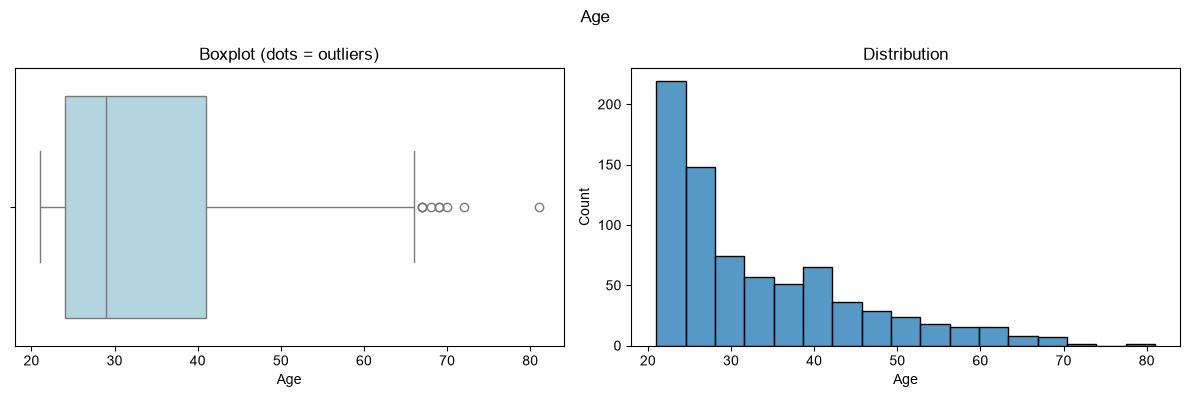

In [31]:
print("Pregnancies")
graphe_check_outliers(df_final, "Pregnancies")
print("Glucose")
graphe_check_outliers(df_final, "Glucose")
print("BloodPressure")
graphe_check_outliers(df_final, "BloodPressure")
print("SkinThickness")
graphe_check_outliers(df_final, "SkinThickness")
print("Insulin")
graphe_check_outliers(df_final, "Insulin")
print("BMI")
graphe_check_outliers(df_final, "BMI")
print("DiabetesPedigreeFunction")
graphe_check_outliers(df_final, "DiabetesPedigreeFunction")
print("Age")
graphe_check_outliers(df_final, "Age")

In [32]:
df_final[df['Insulin'] > 300][['Insulin']].count()


Insulin    37
dtype: int64

In [33]:
df_final[df['DiabetesPedigreeFunction'] > 1.5]['DiabetesPedigreeFunction'].count()


np.int64(10)

In [34]:
df_final = cap_column(df_final, "BloodPressure", min_value=40)
df_final = cap_column(df_final, "Insulin", max_value=300) 

In [35]:
column_info(df_final, "BloodPressure")


,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,69
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,40.0
6,Distribution,Max,122.0
7,Distribution,Mean,72.44
8,Distribution,Median,72.0
9,Distribution,Std deviation,12.04


In [36]:
column_info(df_final, "Insulin")

,Section,Metric,Value
0,General,Data type,float64
1,General,Total rows,768
2,General,Unique values,435
3,Quality,Missing (NaN),0 (0.0%)
4,Quality,Zeros,0 (0.0%)
5,Distribution,Min,14.0
6,Distribution,Max,300.0
7,Distribution,Mean,146.29
8,Distribution,Median,130.0
9,Distribution,Std deviation,74.36


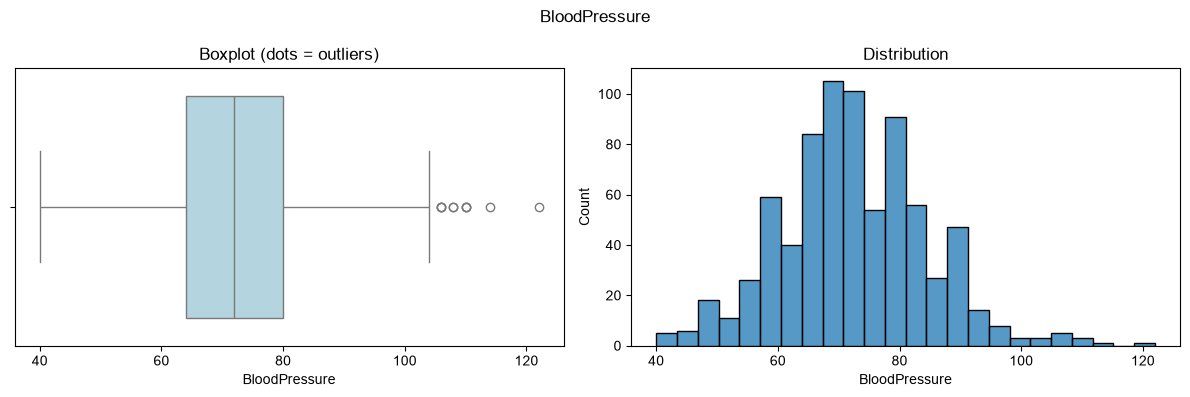

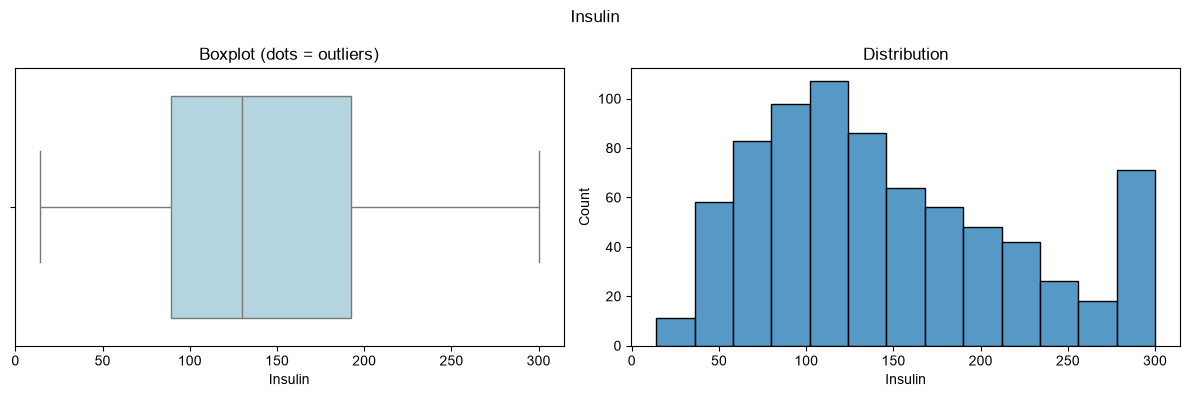

In [37]:
graphe_check_outliers(df_final, "BloodPressure")
graphe_check_outliers(df_final, "Insulin")

start work to find K 

In [38]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


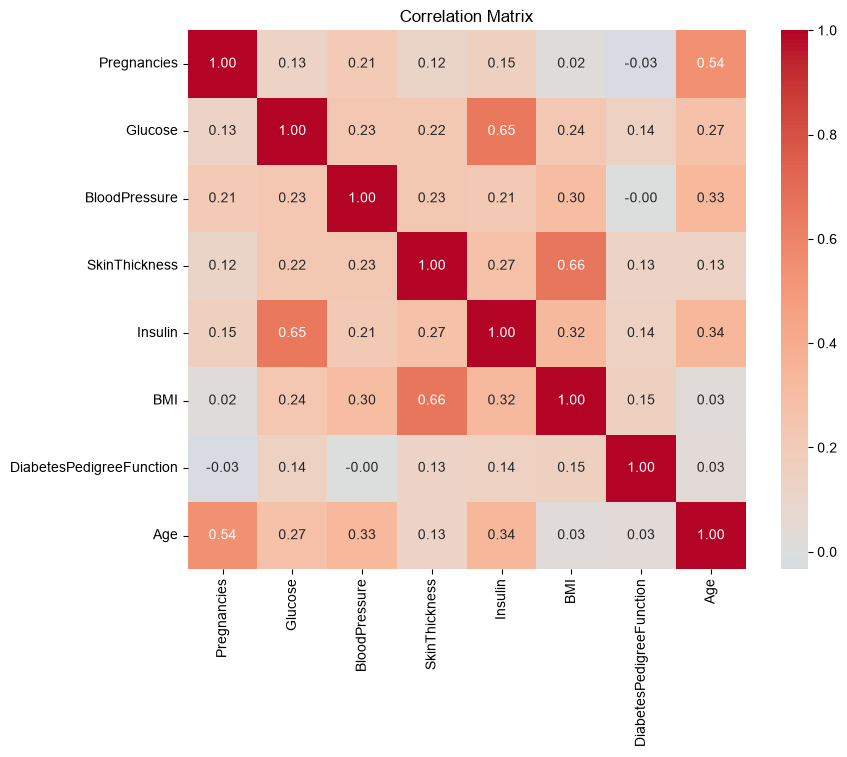

In [39]:
corr = df_final.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [40]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

In [41]:
df_scaled, scaler = scale_column(df_final, features)

df_scaled[features].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02
mean,2.474872e-16,-3.920475e-16,-1.040834e-16,1.873501e-16,-4.487151e-16,2.451743e-16,1.931325e-16
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00
min,-2.547951e+00,-2.696689e+00,-2.325464e+00,-1.780134e+00,-2.066309e+00,-1.189553e+00,-1.041549e+00
25%,-7.419246e-01,-7.013708e-01,-6.552592e-01,-7.655135e-01,-7.157242e-01,-6.889685e-01,-7.862862e-01
50%,-1.508614e-01,-3.626474e-02,-2.100419e-02,-2.191797e-01,-3.462310e-02,-3.001282e-01,-3.608474e-01
75%,6.125953e-01,6.288413e-01,6.343926e-01,6.205058e-01,6.058153e-01,4.662269e-01,6.602056e-01
max,2.541760e+00,4.120648e+00,7.399779e+00,2.068425e+00,5.035151e+00,5.883565e+00,4.063716e+00


In [55]:
wcss = []
# WCSS is simply the total distance between all 
# the data points and their respective centroids
k = 1
while k < 11 :
    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42)
    kmeans.fit(df_scaled[features]) 
    wcss.append(kmeans.inertia_)
    k+=1
print([round(w) for w in wcss])

[5376, 4071, 3594, 3303, 2998, 2747, 2632, 2480, 2403, 2320]


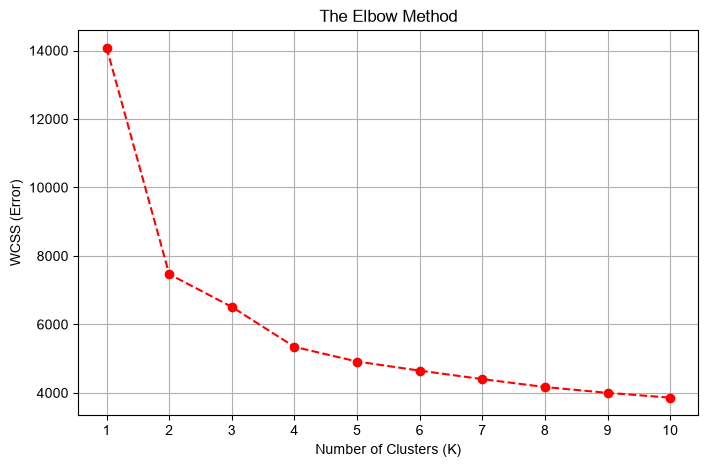

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='r')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Error)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [44]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(df_scaled[features])
    score = silhouette_score(df_scaled[features], labels)
    silhouette_scores.append(score)

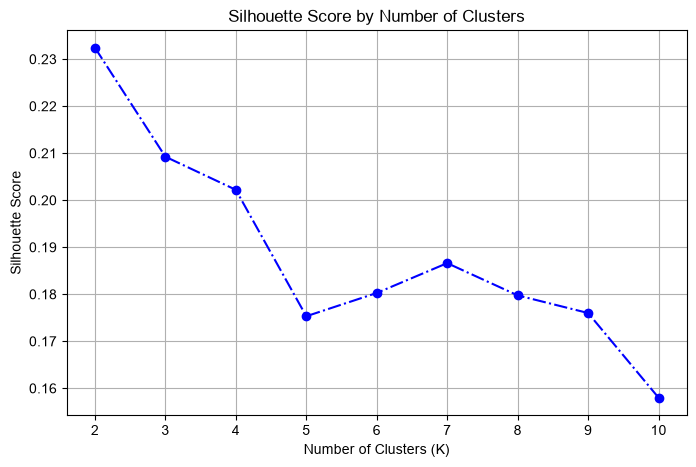

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-.', color='b')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [46]:
kmeans = KMeans(n_clusters=2,random_state=42,init="k-means++")
df_final['Cluster'] = kmeans.fit_predict(df_scaled[features])
df_final['Cluster'].value_counts()

Cluster
1    433
0    335
Name: count, dtype: int64

In [47]:
df_final.groupby('Cluster')[features].mean()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,
0,143.470448,78.596418,33.432836,202.349851,35.855701,0.528570,40.208955
1,104.669284,67.670208,25.568129,102.914550,29.776813,0.428014,27.849885


In [48]:
df_final['risk_category'] = df_final['Cluster'].map({0: 'high risk', 1: 'low risk'})
df_final['risk_category'].value_counts()

risk_category
low risk     433
high risk    335
Name: count, dtype: int64

In [49]:
df_final.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,risk_category
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0,0,high risk
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0,1,low risk
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0,0,high risk
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,1,low risk
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,0,high risk


In [50]:
df_final.to_csv("../data/processed/diabetes_clustered.csv", index=False)

In [51]:
print(kmeans.n_clusters)
print(kmeans.cluster_centers_.shape)
print(kmeans.inertia_)
print(scaler.n_features_in_)
print(list(scaler.feature_names_in_))

2
(2, 7)
4071.3518506905766
7
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [52]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.joblib")
joblib.dump(scaler, "../models/cluster_scaler.joblib")

sil = silhouette_score(df_scaled[features], df_final["Cluster"])
print(sil)

0.23243877767503515
